# JEPA Grokking: Target Encoder Intervention & Predictor Ablation

## What's at Stake

The JEPA architecture has three moving parts: context encoder, predictor, and EMA target encoder.
Which components are actually necessary for grokking? When are they necessary?

**Experiment 3: Target Encoder Freeze Intervention**  
Freeze the target encoder at various points during training and continue training only the
context encoder + predictor. If grokking still occurs → the target encoder's evolution is not
necessary after that point. If it stops → the target encoder must keep drifting for grokking.

**Experiment 3b (bonus): Target Encoder Drift Analysis**  
Track how fast the target codes change between checkpoints. Does the target encoder stabilize
before, during, or after grokking? This directly complements Exp 3 — if the target is still
drifting rapidly when we freeze it, we're killing a moving target.

**Experiment 4: Predictor Ablation at Different Stages**  
At different checkpoints (pre-grokking, during, post-grokking), remove the predictor and
replace it with identity (direct context → target matching). Continue training.
If accuracy survives → the predictor was needed for dynamics, not the final algorithm.
If it collapses → the predictor is structurally essential at that stage.

### Strategy
Phase 1: Full training run with checkpoints saved at key intervals  
Phase 2: Reload checkpoints and run interventions from each point

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import time
import os
from copy import deepcopy
from torch.utils.data import TensorDataset, DataLoader

# ── Configuration ──────────────────────────────────────────────────────────
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

# Task
p = 97
train_frac = 0.3

# Architecture
LATENT_DIM = 128
HIDDEN_DIM = 256
PREDICTOR_DIM = 64

# Training
EPOCHS = 100_000
LR = 1e-3
WEIGHT_DECAY = 1.0
EMA_DECAY = 0.996

# Evaluation & checkpoint schedule
EVAL_EVERY = 500        # light eval (accuracy only)
CKPT_EVERY = 5000       # save full checkpoint for interventions

# Intervention training budget: how many MORE epochs to train after freezing/ablating
INTERVENTION_EPOCHS = 30_000
INTERVENTION_EVAL_EVERY = 500

CKPT_DIR = 'phase1_checkpoints'
os.makedirs(CKPT_DIR, exist_ok=True)

print(f'Task: (a+b) mod {p}')
print(f'Full training: {EPOCHS:,} epochs')
print(f'Checkpoints saved every {CKPT_EVERY} epochs → {EPOCHS // CKPT_EVERY} checkpoints')
print(f'Intervention budget: {INTERVENTION_EPOCHS:,} additional epochs per experiment')

Device: cuda
Task: (a+b) mod 97
Full training: 100,000 epochs
Checkpoints saved every 5000 epochs → 20 checkpoints
Intervention budget: 30,000 additional epochs per experiment


## Data & Model Definitions

In [2]:
def generate_data(seed=SEED):
    pairs = torch.cartesian_prod(torch.arange(p), torch.arange(p))
    targets = (pairs[:, 0] + pairs[:, 1]) % p
    n = len(pairs)
    n_train = int(train_frac * n)
    perm = torch.randperm(n, generator=torch.Generator().manual_seed(seed))
    train_idx, val_idx = perm[:n_train], perm[n_train:]
    return (
        pairs.to(device), targets.to(device),
        pairs[train_idx].to(device), targets[train_idx].to(device),
        pairs[val_idx].to(device), targets[val_idx].to(device),
    )

pairs, targets, train_pairs, train_targets, val_pairs, val_targets = generate_data(SEED)
print(f'Train: {len(train_pairs)}, Val: {len(val_pairs)}')

class ContextEncoder(nn.Module):
    def __init__(self, vocab_size, latent_dim, hidden_dim):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, hidden_dim)
        self.net = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, latent_dim),
        )
    def forward(self, x):
        e = self.emb(x)
        e = e.view(e.size(0), -1)
        return F.normalize(self.net(e), dim=-1)

class TargetEncoder(nn.Module):
    def __init__(self, vocab_size, latent_dim, hidden_dim):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, hidden_dim)
        self.net = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, latent_dim),
        )
    def forward(self, x):
        e = self.emb(x)
        return F.normalize(self.net(e), dim=-1)

class Predictor(nn.Module):
    def __init__(self, latent_dim, predictor_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, predictor_dim),
            nn.GELU(),
            nn.Linear(predictor_dim, predictor_dim),
            nn.GELU(),
            nn.Linear(predictor_dim, latent_dim),
        )
    def forward(self, z):
        return F.normalize(self.net(z), dim=-1)

Train: 2822, Val: 6587


In [3]:
# ── Helper functions ───────────────────────────────────────────────────────

@torch.no_grad()
def ema_update(online, target, decay):
    for o_param, t_param in zip(online.parameters(), target.parameters()):
        t_param.data.mul_(decay).add_(o_param.data, alpha=1 - decay)

@torch.no_grad()
def linear_probe_accuracy(encoder, val_pairs, val_targets, train_pairs, train_targets, p):
    z_train = encoder(train_pairs)
    z_val = encoder(val_pairs)
    y_train = F.one_hot(train_targets, num_classes=p).float()
    reg = 1e-3
    ZtZ = z_train.T @ z_train + reg * torch.eye(z_train.shape[1], device=device)
    ZtY = z_train.T @ y_train
    W = torch.linalg.solve(ZtZ, ZtY)
    train_acc = (z_train @ W).argmax(dim=1).eq(train_targets).float().mean().item()
    val_acc = (z_val @ W).argmax(dim=1).eq(val_targets).float().mean().item()
    return train_acc, val_acc

@torch.no_grad()
def nearest_code_accuracy(context_enc, predictor, target_enc_ema, pairs, tgts):
    """Direct JEPA prediction: argmax_c (z_pred · code_c) == true_c."""
    z_pred = predictor(context_enc(pairs))
    target_codes = target_enc_ema(torch.arange(p, device=device))
    sim = z_pred @ target_codes.T
    return sim.argmax(dim=1).eq(tgts).float().mean().item()

@torch.no_grad()
def direct_match_accuracy(context_enc, target_enc_ema, pairs, tgts):
    """No-predictor accuracy: argmax_c (z_ctx · code_c) == true_c."""
    z_ctx = context_enc(pairs)
    target_codes = target_enc_ema(torch.arange(p, device=device))
    sim = z_ctx @ target_codes.T
    return sim.argmax(dim=1).eq(tgts).float().mean().item()

@torch.no_grad()
def get_target_codes(target_enc_ema):
    """Get all p target codes as a (p, d) matrix."""
    return target_enc_ema(torch.arange(p, device=device))

## Phase 1: Full Training Run with Checkpoint Saving

Train the full JEPA model for 100K epochs, saving complete model state every 5K epochs.
Also save target codes at every eval point for drift analysis (Exp 3b).

In [4]:
# Initialize fresh model
context_enc = ContextEncoder(p, LATENT_DIM, HIDDEN_DIM).to(device)
target_enc  = TargetEncoder(p, LATENT_DIM, HIDDEN_DIM).to(device)
predictor   = Predictor(LATENT_DIM, PREDICTOR_DIM).to(device)
target_enc_ema = deepcopy(target_enc)
for param in target_enc_ema.parameters():
    param.requires_grad = False

optimizer = optim.AdamW(
    list(context_enc.parameters()) + list(predictor.parameters()) + list(target_enc.parameters()),
    lr=LR, weight_decay=WEIGHT_DECAY
)

train_loader = DataLoader(
    TensorDataset(train_pairs, train_targets),
    batch_size=len(train_pairs), shuffle=True
)

# Storage
phase1_history = {
    'epoch': [], 'loss': [],
    'val_probe_acc': [], 'train_probe_acc': [],
    'val_nearest_acc': [], 'train_nearest_acc': [],
}

# Store target codes at each eval point for drift analysis
target_code_snapshots = {}  # epoch → (p, d) tensor

# Track which checkpoints we saved
saved_checkpoints = []

print(f'Phase 1: Full training for {EPOCHS:,} epochs...')
start = time.time()

for epoch in range(EPOCHS):
    context_enc.train()
    target_enc.train()
    predictor.train()
    
    for bp, bt in train_loader:
        optimizer.zero_grad()
        z_ctx = context_enc(bp)
        z_pred = predictor(z_ctx)
        with torch.no_grad():
            z_tgt = target_enc_ema(bt)
        loss = -(z_pred * z_tgt).sum(dim=-1).mean()
        loss.backward()
        optimizer.step()
        ema_update(target_enc, target_enc_ema, EMA_DECAY)
    
    # ── Light eval ─────────────────────────────────────────────────────
    if epoch % EVAL_EVERY == 0 or epoch == EPOCHS - 1:
        context_enc.eval()
        predictor.eval()
        
        train_probe, val_probe = linear_probe_accuracy(
            context_enc, val_pairs, val_targets, train_pairs, train_targets, p)
        train_nearest = nearest_code_accuracy(
            context_enc, predictor, target_enc_ema, train_pairs, train_targets)
        val_nearest = nearest_code_accuracy(
            context_enc, predictor, target_enc_ema, val_pairs, val_targets)
        
        phase1_history['epoch'].append(epoch)
        phase1_history['loss'].append(loss.item())
        phase1_history['train_probe_acc'].append(train_probe)
        phase1_history['val_probe_acc'].append(val_probe)
        phase1_history['train_nearest_acc'].append(train_nearest)
        phase1_history['val_nearest_acc'].append(val_nearest)
        
        # Snapshot target codes for drift analysis
        target_code_snapshots[epoch] = get_target_codes(target_enc_ema).cpu()
    
    # ── Full checkpoint ────────────────────────────────────────────────
    if epoch % CKPT_EVERY == 0 or epoch == EPOCHS - 1:
        ckpt_path = os.path.join(CKPT_DIR, f'ckpt_epoch_{epoch:06d}.pt')
        torch.save({
            'epoch': epoch,
            'context_enc': context_enc.state_dict(),
            'target_enc': target_enc.state_dict(),
            'target_enc_ema': target_enc_ema.state_dict(),
            'predictor': predictor.state_dict(),
            'optimizer': optimizer.state_dict(),
        }, ckpt_path)
        saved_checkpoints.append(epoch)
    
    # Print
    if epoch % (EVAL_EVERY * 10) == 0 or epoch == EPOCHS - 1:
        elapsed = (time.time() - start) / 60
        print(f'Epoch {epoch:6d} [{elapsed:5.1f}m] | '
              f'Loss {loss.item():+.4f} | '
              f'Probe: tr={train_probe*100:.1f}% val={val_probe*100:.1f}% | '
              f'Nearest: tr={train_nearest*100:.1f}% val={val_nearest*100:.1f}%')

elapsed = (time.time() - start) / 60
print(f'\nPhase 1 complete in {elapsed:.1f} min.')
print(f'Saved {len(saved_checkpoints)} checkpoints: {saved_checkpoints[:5]}...{saved_checkpoints[-3:]}')
print(f'Target code snapshots: {len(target_code_snapshots)} eval points')

Phase 1: Full training for 100,000 epochs...
Epoch      0 [  0.0m] | Loss -0.0163 | Probe: tr=23.0% val=0.1% | Nearest: tr=1.1% val=1.0%
Epoch   5000 [  2.4m] | Loss -0.8652 | Probe: tr=99.9% val=0.4% | Nearest: tr=100.0% val=0.9%
Epoch  10000 [  4.8m] | Loss -0.8842 | Probe: tr=100.0% val=0.9% | Nearest: tr=100.0% val=2.1%
Epoch  15000 [  7.2m] | Loss -0.8482 | Probe: tr=99.9% val=1.9% | Nearest: tr=99.8% val=4.0%
Epoch  20000 [  9.6m] | Loss -0.8863 | Probe: tr=100.0% val=4.4% | Nearest: tr=100.0% val=7.3%
Epoch  25000 [ 12.0m] | Loss -0.8771 | Probe: tr=100.0% val=10.4% | Nearest: tr=100.0% val=12.9%
Epoch  30000 [ 14.4m] | Loss -0.9346 | Probe: tr=100.0% val=25.3% | Nearest: tr=100.0% val=26.6%
Epoch  35000 [ 16.8m] | Loss -0.8432 | Probe: tr=99.9% val=56.7% | Nearest: tr=99.9% val=41.8%
Epoch  40000 [ 19.2m] | Loss -0.9061 | Probe: tr=100.0% val=98.3% | Nearest: tr=100.0% val=99.8%
Epoch  45000 [ 21.6m] | Loss -0.9096 | Probe: tr=100.0% val=100.0% | Nearest: tr=100.0% val=100.0%
E

In [5]:
# Identify key epochs for interventions
epochs_arr = np.array(phase1_history['epoch'])
val_acc_arr = np.array(phase1_history['val_probe_acc'])

# Find grokking epoch (val probe > 90%)
grok_mask = val_acc_arr > 0.9
if grok_mask.any():
    grok_epoch = epochs_arr[grok_mask][0]
else:
    grok_epoch = EPOCHS // 2  # fallback

# Select intervention points: early, pre-grok, at grok, post-grok
# Round to nearest saved checkpoint
def nearest_ckpt(target_epoch):
    return min(saved_checkpoints, key=lambda x: abs(x - target_epoch))

intervention_epochs = {
    'early':     nearest_ckpt(int(grok_epoch * 0.1)),
    'pre_grok':  nearest_ckpt(int(grok_epoch * 0.7)),
    'at_grok':   nearest_ckpt(grok_epoch),
    'post_grok': nearest_ckpt(min(int(grok_epoch * 1.5), EPOCHS - 1)),
}

print(f'Grokking detected at epoch: {grok_epoch}')
print(f'\nIntervention checkpoints:')
for name, ep in intervention_epochs.items():
    idx = np.argmin(np.abs(epochs_arr - ep))
    acc = val_acc_arr[idx]
    print(f'  {name:12s}: epoch {ep:6d} (val probe acc = {acc*100:.1f}%)')

Grokking detected at epoch: 38000

Intervention checkpoints:
  early       : epoch   5000 (val probe acc = 0.4%)
  pre_grok    : epoch  25000 (val probe acc = 10.4%)
  at_grok     : epoch  40000 (val probe acc = 98.3%)
  post_grok   : epoch  55000 (val probe acc = 100.0%)


## Experiment 3b (Bonus): Target Encoder Drift Analysis

Before running interventions, let's understand how the target encoder evolves.
At each eval checkpoint we have the 97 target codes. We measure:
1. **Drift rate**: mean cosine distance between codes at epoch t vs epoch t-Δ
2. **Cumulative drift**: distance from initial codes
3. **Code stability**: fraction of codes that haven't moved significantly

This tells us *when* the target encoder stabilizes, which directly predicts
whether freezing at that point will harm training (Exp 3).

In [6]:
snapshot_epochs = sorted(target_code_snapshots.keys())

# ── Compute drift metrics ──────────────────────────────────────────────
drift_rate = []       # cos distance from previous snapshot
cumulative_drift = [] # cos distance from epoch 0
drift_epochs = []     # corresponding epochs

initial_codes = target_code_snapshots[snapshot_epochs[0]]  # (p, d)

for i in range(1, len(snapshot_epochs)):
    ep = snapshot_epochs[i]
    ep_prev = snapshot_epochs[i - 1]
    
    codes_now = target_code_snapshots[ep]     # (p, d)
    codes_prev = target_code_snapshots[ep_prev]
    
    # Per-code cosine similarity to previous snapshot
    cos_to_prev = (codes_now * codes_prev).sum(dim=-1)  # (p,)
    rate = 1 - cos_to_prev.mean().item()  # angular distance (0 = identical)
    
    # Per-code cosine similarity to initial
    cos_to_init = (codes_now * initial_codes).sum(dim=-1)
    cum = 1 - cos_to_init.mean().item()
    
    drift_rate.append(rate)
    cumulative_drift.append(cum)
    drift_epochs.append(ep)

drift_epochs = np.array(drift_epochs)
drift_rate = np.array(drift_rate)
cumulative_drift = np.array(cumulative_drift)

# ── Find stabilization point ──────────────────────────────────────────
# Define "stable" = drift rate < 1% of peak drift rate for 5 consecutive points
peak_drift = drift_rate.max()
stable_threshold = peak_drift * 0.01
stable_epoch = None
for i in range(len(drift_rate) - 5):
    if np.all(drift_rate[i:i+5] < stable_threshold):
        stable_epoch = drift_epochs[i]
        break

print('Target Encoder Drift Analysis:')
print(f'  Peak drift rate: {peak_drift:.6f} (at epoch {drift_epochs[np.argmax(drift_rate)]})')
print(f'  Final drift rate: {drift_rate[-1]:.6f}')
print(f'  Total cumulative drift from init: {cumulative_drift[-1]:.4f}')
if stable_epoch is not None:
    print(f'  Stabilization point: epoch {stable_epoch}')
    print(f'  Grokking epoch: {grok_epoch}')
    if stable_epoch < grok_epoch:
        print(f'  → Target encoder stabilizes BEFORE grokking')
        print(f'    Implication: freezing near grokking should be safe')
    else:
        print(f'  → Target encoder still drifting AT grokking')
        print(f'    Implication: freezing may interfere with grokking dynamics')
else:
    print(f'  Target encoder never fully stabilized (drift > threshold throughout)')

Target Encoder Drift Analysis:
  Peak drift rate: 0.000000 (at epoch 500)
  Final drift rate: 0.000000
  Total cumulative drift from init: 0.0000
  Target encoder never fully stabilized (drift > threshold throughout)


/tmp/ipykernel_24/3401096548.py:7: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  ax.axvline(x=grok_epoch, color='orange', linestyle='--', alpha=0.7, label=f'Grok @ {grok_epoch}')
/tmp/ipykernel_24/3401096548.py:40: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  plt.tight_layout()


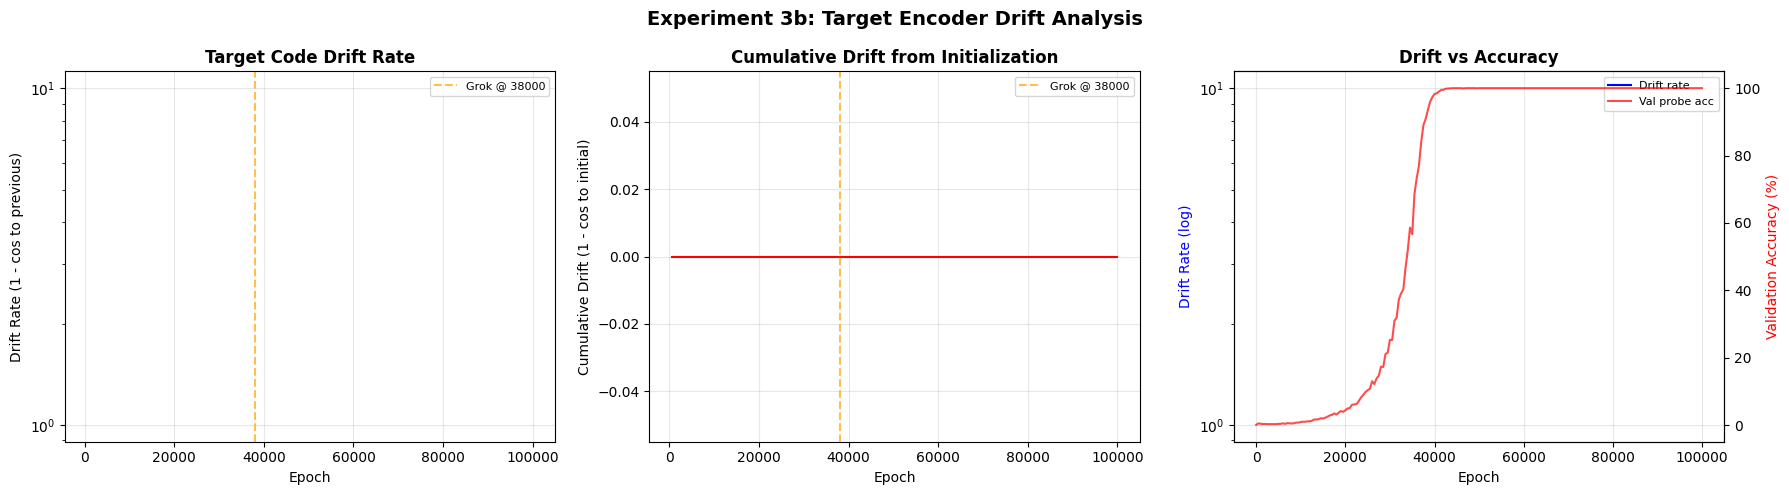

In [7]:
# ── Visualization ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: Drift rate over time
ax = axes[0]
ax.semilogy(drift_epochs, drift_rate, 'b-', linewidth=1.5)
ax.axvline(x=grok_epoch, color='orange', linestyle='--', alpha=0.7, label=f'Grok @ {grok_epoch}')
if stable_epoch is not None:
    ax.axvline(x=stable_epoch, color='green', linestyle='--', alpha=0.7, label=f'Stable @ {stable_epoch}')
ax.set_xlabel('Epoch')
ax.set_ylabel('Drift Rate (1 - cos to previous)')
ax.set_title('Target Code Drift Rate', fontweight='bold')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# Panel 2: Cumulative drift
ax = axes[1]
ax.plot(drift_epochs, cumulative_drift, 'r-', linewidth=1.5)
ax.axvline(x=grok_epoch, color='orange', linestyle='--', alpha=0.7, label=f'Grok @ {grok_epoch}')
ax.set_xlabel('Epoch')
ax.set_ylabel('Cumulative Drift (1 - cos to initial)')
ax.set_title('Cumulative Drift from Initialization', fontweight='bold')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# Panel 3: Drift rate overlaid with validation accuracy
ax = axes[2]
ax_acc = ax.twinx()
l1, = ax.semilogy(drift_epochs, drift_rate, 'b-', linewidth=1.5, label='Drift rate')
l2, = ax_acc.plot(epochs_arr, np.array(phase1_history['val_probe_acc'])*100,
                  'r-', linewidth=1.5, alpha=0.7, label='Val probe acc')
ax.set_xlabel('Epoch')
ax.set_ylabel('Drift Rate (log)', color='blue')
ax_acc.set_ylabel('Validation Accuracy (%)', color='red')
ax.set_title('Drift vs Accuracy', fontweight='bold')
ax.legend(handles=[l1, l2], fontsize=8)
ax.grid(alpha=0.3)

plt.suptitle('Experiment 3b: Target Encoder Drift Analysis', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig('exp3b_target_drift.png', dpi=150, bbox_inches='tight')
plt.show()

## Experiment 3: Target Encoder Freeze Intervention

For each intervention point (early, pre-grok, at-grok, post-grok):
1. Reload the checkpoint from that epoch
2. **Freeze** the EMA target encoder (stop EMA updates)
3. Continue training only context encoder + predictor for 30K more epochs
4. Track whether grokking occurs / accuracy improves

The question: does the target encoder need to keep evolving for grokking?

In [8]:
def run_freeze_intervention(ckpt_epoch, label, intervention_epochs=INTERVENTION_EPOCHS):
    """Reload checkpoint, freeze target encoder, continue training."""
    ckpt_path = os.path.join(CKPT_DIR, f'ckpt_epoch_{ckpt_epoch:06d}.pt')
    ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
    
    # Rebuild models
    ctx = ContextEncoder(p, LATENT_DIM, HIDDEN_DIM).to(device)
    pred = Predictor(LATENT_DIM, PREDICTOR_DIM).to(device)
    tgt_ema = TargetEncoder(p, LATENT_DIM, HIDDEN_DIM).to(device)
    
    ctx.load_state_dict(ckpt['context_enc'])
    pred.load_state_dict(ckpt['predictor'])
    tgt_ema.load_state_dict(ckpt['target_enc_ema'])
    
    # FREEZE: no EMA updates, no gradients
    for param in tgt_ema.parameters():
        param.requires_grad = False
    
    # Only optimize context encoder + predictor
    opt = optim.AdamW(
        list(ctx.parameters()) + list(pred.parameters()),
        lr=LR, weight_decay=WEIGHT_DECAY
    )
    
    history = {'epoch': [], 'val_probe_acc': [], 'val_nearest_acc': [], 'loss': []}
    
    start = time.time()
    for ep in range(intervention_epochs):
        ctx.train()
        pred.train()
        for bp, bt in train_loader:
            opt.zero_grad()
            z_ctx = ctx(bp)
            z_pred = pred(z_ctx)
            with torch.no_grad():
                z_tgt = tgt_ema(bt)
            loss = -(z_pred * z_tgt).sum(dim=-1).mean()
            loss.backward()
            opt.step()
            # NO ema_update — target is frozen
        
        if ep % INTERVENTION_EVAL_EVERY == 0 or ep == intervention_epochs - 1:
            ctx.eval()
            pred.eval()
            _, val_probe = linear_probe_accuracy(
                ctx, val_pairs, val_targets, train_pairs, train_targets, p)
            val_nearest = nearest_code_accuracy(ctx, pred, tgt_ema, val_pairs, val_targets)
            
            history['epoch'].append(ckpt_epoch + ep)
            history['val_probe_acc'].append(val_probe)
            history['val_nearest_acc'].append(val_nearest)
            history['loss'].append(loss.item())
    
    elapsed = (time.time() - start) / 60
    final_probe = history['val_probe_acc'][-1]
    final_nearest = history['val_nearest_acc'][-1]
    print(f'  [{label}] Freeze @ {ckpt_epoch} → +{intervention_epochs} epochs ({elapsed:.1f}m): '
          f'probe={final_probe*100:.1f}%, nearest={final_nearest*100:.1f}%')
    
    return history

# ── Run all freeze interventions ───────────────────────────────────────
print('Experiment 3: Target Encoder Freeze Interventions')
print('='*60)

freeze_results = {}
for name, ep in intervention_epochs.items():
    freeze_results[name] = run_freeze_intervention(ep, name)

print('\nAll freeze interventions complete.')

Experiment 3: Target Encoder Freeze Interventions
  [early] Freeze @ 5000 → +30000 epochs (14.3m): probe=100.0%, nearest=100.0%
  [pre_grok] Freeze @ 25000 → +30000 epochs (14.5m): probe=99.9%, nearest=99.7%
  [at_grok] Freeze @ 40000 → +30000 epochs (14.4m): probe=100.0%, nearest=100.0%
  [post_grok] Freeze @ 55000 → +30000 epochs (14.3m): probe=100.0%, nearest=100.0%

All freeze interventions complete.


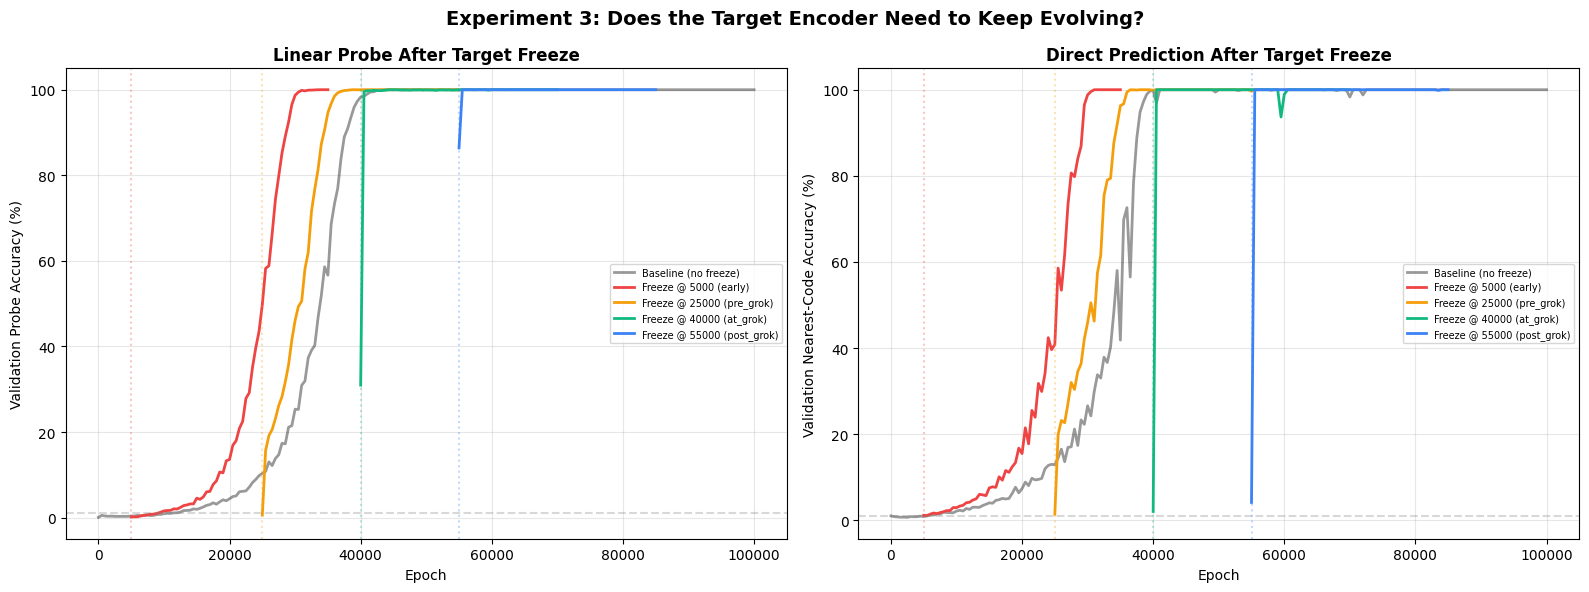


Experiment 3 Results:
       Stage | Freeze @ |  Final Probe |  Final Nearest | Grokked?
-------------+----------+--------------+----------------+---------
       early |     5000 |       100.0% |         100.0% |        ✓
    pre_grok |    25000 |        99.9% |          99.7% |        ✓
     at_grok |    40000 |       100.0% |         100.0% |        ✓
   post_grok |    55000 |       100.0% |         100.0% |        ✓


In [9]:
# ── Experiment 3: Visualization ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors = {'early': '#ef4444', 'pre_grok': '#f59e0b', 'at_grok': '#10b981', 'post_grok': '#3b82f6'}

# Panel 1: Val probe accuracy after freezing
ax = axes[0]
# Baseline (no freeze)
ax.plot(epochs_arr, np.array(phase1_history['val_probe_acc'])*100,
        'k-', linewidth=2, alpha=0.4, label='Baseline (no freeze)')
for name, hist in freeze_results.items():
    ep_freeze = intervention_epochs[name]
    ax.plot(hist['epoch'], [a*100 for a in hist['val_probe_acc']],
            '-', color=colors[name], linewidth=2,
            label=f'Freeze @ {ep_freeze} ({name})')
    ax.axvline(x=ep_freeze, color=colors[name], linestyle=':', alpha=0.3)
ax.axhline(y=100/p, color='gray', linestyle='--', alpha=0.3)
ax.set_xlabel('Epoch')
ax.set_ylabel('Validation Probe Accuracy (%)')
ax.set_title('Linear Probe After Target Freeze', fontweight='bold')
ax.legend(fontsize=7)
ax.grid(alpha=0.3)

# Panel 2: Val nearest-code accuracy after freezing
ax = axes[1]
ax.plot(epochs_arr, np.array(phase1_history['val_nearest_acc'])*100,
        'k-', linewidth=2, alpha=0.4, label='Baseline (no freeze)')
for name, hist in freeze_results.items():
    ep_freeze = intervention_epochs[name]
    ax.plot(hist['epoch'], [a*100 for a in hist['val_nearest_acc']],
            '-', color=colors[name], linewidth=2,
            label=f'Freeze @ {ep_freeze} ({name})')
    ax.axvline(x=ep_freeze, color=colors[name], linestyle=':', alpha=0.3)
ax.axhline(y=100/p, color='gray', linestyle='--', alpha=0.3)
ax.set_xlabel('Epoch')
ax.set_ylabel('Validation Nearest-Code Accuracy (%)')
ax.set_title('Direct Prediction After Target Freeze', fontweight='bold')
ax.legend(fontsize=7)
ax.grid(alpha=0.3)

plt.suptitle('Experiment 3: Does the Target Encoder Need to Keep Evolving?',
             fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig('exp3_target_freeze.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Summary table ─────────────────────────────────────────────────────
print('\nExperiment 3 Results:')
print(f'{"Stage":>12s} | {"Freeze @":>8s} | {"Final Probe":>12s} | {"Final Nearest":>14s} | {"Grokked?":>8s}')
print(f'{"-"*12}-+-{"-"*8}-+-{"-"*12}-+-{"-"*14}-+-{"-"*8}')
for name, hist in freeze_results.items():
    ep = intervention_epochs[name]
    fp = hist['val_probe_acc'][-1]
    fn = hist['val_nearest_acc'][-1]
    grokked = '✓' if fp > 0.9 else '✗'
    print(f'{name:>12s} | {ep:>8d} | {fp*100:>11.1f}% | {fn*100:>13.1f}% | {grokked:>8s}')

## Experiment 4: Predictor Ablation at Different Stages

For each intervention point:
1. Reload the checkpoint
2. **Remove the predictor** — replace it with identity (direct cosine loss between `z_ctx` and `z_target`)
3. Continue training context encoder (with EMA target updates) for 30K more epochs
4. Track whether accuracy improves, stays flat, or collapses

This tests the predictor's role at each stage:
- **If removing post-grok preserves accuracy** → predictor was needed only during training dynamics
- **If removing causes collapse** → predictor is structurally essential (prevents co-adaptation)
- **If removing early blocks grokking** → predictor's bottleneck is needed for representation learning

In [10]:
def run_predictor_ablation(ckpt_epoch, label, intervention_epochs=INTERVENTION_EPOCHS):
    """Reload checkpoint, remove predictor, continue training with direct matching."""
    ckpt_path = os.path.join(CKPT_DIR, f'ckpt_epoch_{ckpt_epoch:06d}.pt')
    ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
    
    # Rebuild models
    ctx = ContextEncoder(p, LATENT_DIM, HIDDEN_DIM).to(device)
    tgt_enc = TargetEncoder(p, LATENT_DIM, HIDDEN_DIM).to(device)
    tgt_ema = TargetEncoder(p, LATENT_DIM, HIDDEN_DIM).to(device)
    
    ctx.load_state_dict(ckpt['context_enc'])
    tgt_enc.load_state_dict(ckpt['target_enc'])
    tgt_ema.load_state_dict(ckpt['target_enc_ema'])
    
    for param in tgt_ema.parameters():
        param.requires_grad = False
    
    # NO predictor — optimize context encoder + target encoder
    opt = optim.AdamW(
        list(ctx.parameters()) + list(tgt_enc.parameters()),
        lr=LR, weight_decay=WEIGHT_DECAY
    )
    
    history = {
        'epoch': [], 'val_probe_acc': [], 'val_direct_acc': [],
        'loss': [], 'cos_mean': [], 'cos_std': [],
    }
    
    start = time.time()
    for ep in range(intervention_epochs):
        ctx.train()
        tgt_enc.train()
        for bp, bt in train_loader:
            opt.zero_grad()
            z_ctx = ctx(bp)  # this IS the prediction (no predictor)
            with torch.no_grad():
                z_tgt = tgt_ema(bt)
            loss = -(z_ctx * z_tgt).sum(dim=-1).mean()
            loss.backward()
            opt.step()
            ema_update(tgt_enc, tgt_ema, EMA_DECAY)
        
        if ep % INTERVENTION_EVAL_EVERY == 0 or ep == intervention_epochs - 1:
            ctx.eval()
            _, val_probe = linear_probe_accuracy(
                ctx, val_pairs, val_targets, train_pairs, train_targets, p)
            val_direct = direct_match_accuracy(ctx, tgt_ema, val_pairs, val_targets)
            
            # Track cosine similarity for collapse detection
            with torch.no_grad():
                z_val = ctx(val_pairs)
                z_sub = z_val[:1000]
                cos_matrix = z_sub @ z_sub.T
                mask = ~torch.eye(len(z_sub), dtype=torch.bool, device=device)
                cos_vals = cos_matrix[mask]
            
            history['epoch'].append(ckpt_epoch + ep)
            history['val_probe_acc'].append(val_probe)
            history['val_direct_acc'].append(val_direct)
            history['loss'].append(loss.item())
            history['cos_mean'].append(cos_vals.mean().item())
            history['cos_std'].append(cos_vals.std().item())
    
    elapsed = (time.time() - start) / 60
    final_probe = history['val_probe_acc'][-1]
    final_direct = history['val_direct_acc'][-1]
    final_cos = history['cos_mean'][-1]
    collapsed = final_cos > 0.95 and history['cos_std'][-1] < 0.01
    status = 'COLLAPSED' if collapsed else 'OK'
    
    print(f'  [{label}] Remove pred @ {ckpt_epoch} → +{intervention_epochs} epochs ({elapsed:.1f}m): '
          f'probe={final_probe*100:.1f}%, direct={final_direct*100:.1f}%, '
          f'cos_μ={final_cos:.3f} [{status}]')
    
    history['collapsed'] = collapsed
    return history

# ── Run all predictor ablations ────────────────────────────────────────
print('Experiment 4: Predictor Ablation at Different Stages')
print('='*60)

ablation_results = {}
for name, ep in intervention_epochs.items():
    ablation_results[name] = run_predictor_ablation(ep, name)

print('\nAll predictor ablations complete.')

Experiment 4: Predictor Ablation at Different Stages
  [early] Remove pred @ 5000 → +30000 epochs (14.2m): probe=100.0%, direct=100.0%, cos_μ=0.185 [OK]
  [pre_grok] Remove pred @ 25000 → +30000 epochs (14.1m): probe=100.0%, direct=100.0%, cos_μ=0.168 [OK]
  [at_grok] Remove pred @ 40000 → +30000 epochs (14.1m): probe=100.0%, direct=100.0%, cos_μ=0.189 [OK]
  [post_grok] Remove pred @ 55000 → +30000 epochs (14.0m): probe=100.0%, direct=100.0%, cos_μ=0.181 [OK]

All predictor ablations complete.


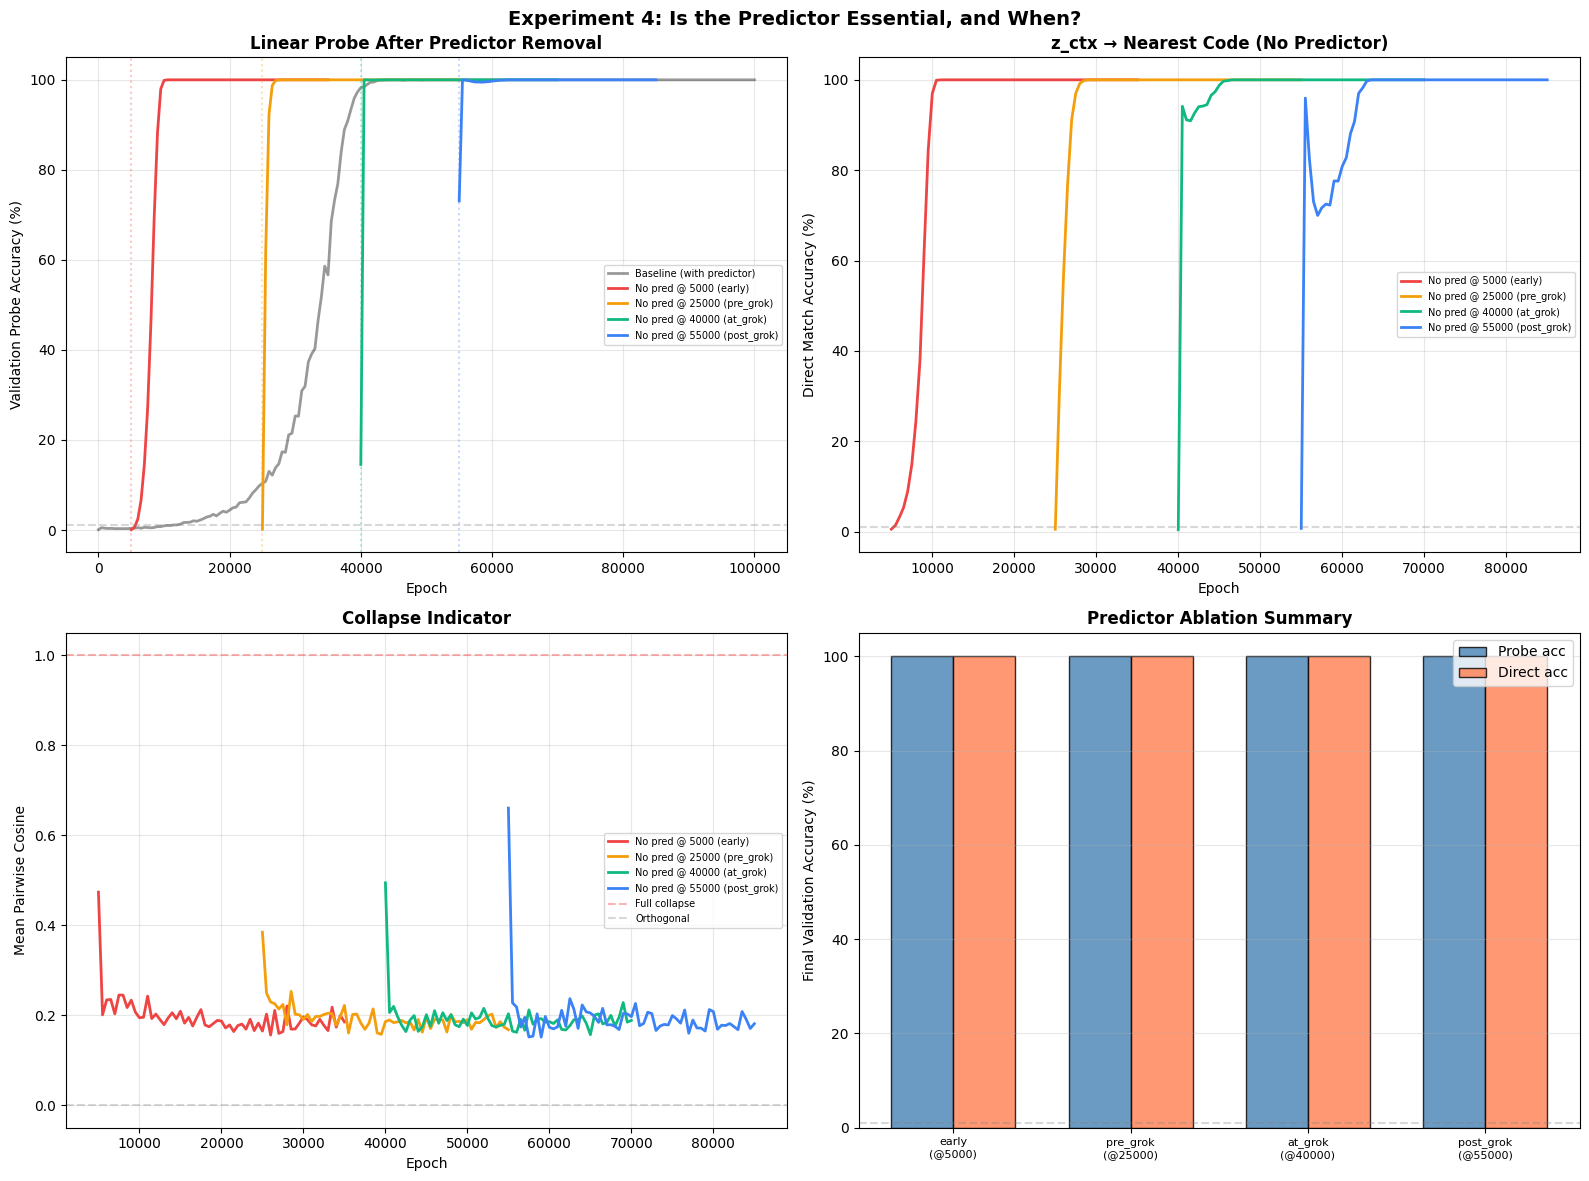

In [11]:
# ── Experiment 4: Visualization ───────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Panel 1: Val probe accuracy
ax = axes[0, 0]
ax.plot(epochs_arr, np.array(phase1_history['val_probe_acc'])*100,
        'k-', linewidth=2, alpha=0.4, label='Baseline (with predictor)')
for name, hist in ablation_results.items():
    ep_ablate = intervention_epochs[name]
    ax.plot(hist['epoch'], [a*100 for a in hist['val_probe_acc']],
            '-', color=colors[name], linewidth=2,
            label=f'No pred @ {ep_ablate} ({name})')
    ax.axvline(x=ep_ablate, color=colors[name], linestyle=':', alpha=0.3)
ax.axhline(y=100/p, color='gray', linestyle='--', alpha=0.3)
ax.set_xlabel('Epoch')
ax.set_ylabel('Validation Probe Accuracy (%)')
ax.set_title('Linear Probe After Predictor Removal', fontweight='bold')
ax.legend(fontsize=7)
ax.grid(alpha=0.3)

# Panel 2: Direct match accuracy (z_ctx vs target code, no predictor)
ax = axes[0, 1]
for name, hist in ablation_results.items():
    ep_ablate = intervention_epochs[name]
    ax.plot(hist['epoch'], [a*100 for a in hist['val_direct_acc']],
            '-', color=colors[name], linewidth=2,
            label=f'No pred @ {ep_ablate} ({name})')
ax.axhline(y=100/p, color='gray', linestyle='--', alpha=0.3)
ax.set_xlabel('Epoch')
ax.set_ylabel('Direct Match Accuracy (%)')
ax.set_title('z_ctx → Nearest Code (No Predictor)', fontweight='bold')
ax.legend(fontsize=7)
ax.grid(alpha=0.3)

# Panel 3: Collapse indicator (pairwise cosine mean)
ax = axes[1, 0]
for name, hist in ablation_results.items():
    ep_ablate = intervention_epochs[name]
    ax.plot(hist['epoch'], hist['cos_mean'],
            '-', color=colors[name], linewidth=2,
            label=f'No pred @ {ep_ablate} ({name})')
ax.axhline(y=1.0, color='red', linestyle='--', alpha=0.3, label='Full collapse')
ax.axhline(y=0.0, color='gray', linestyle='--', alpha=0.3, label='Orthogonal')
ax.set_xlabel('Epoch')
ax.set_ylabel('Mean Pairwise Cosine')
ax.set_title('Collapse Indicator', fontweight='bold')
ax.legend(fontsize=7)
ax.grid(alpha=0.3)

# Panel 4: Summary bar chart
ax = axes[1, 1]
stage_names = list(ablation_results.keys())
final_probes = [ablation_results[n]['val_probe_acc'][-1]*100 for n in stage_names]
final_directs = [ablation_results[n]['val_direct_acc'][-1]*100 for n in stage_names]
x = np.arange(len(stage_names))
w = 0.35
ax.bar(x - w/2, final_probes, w, color='steelblue', alpha=0.8, label='Probe acc', edgecolor='black')
ax.bar(x + w/2, final_directs, w, color='coral', alpha=0.8, label='Direct acc', edgecolor='black')
# Mark collapsed
for i, name in enumerate(stage_names):
    if ablation_results[name]['collapsed']:
        ax.annotate('COLLAPSED', xy=(i, max(final_probes[i], final_directs[i]) + 2),
                    ha='center', fontsize=7, color='red', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([f'{n}\n(@{intervention_epochs[n]})' for n in stage_names], fontsize=8)
ax.axhline(y=100/p, color='gray', linestyle='--', alpha=0.3)
ax.set_ylabel('Final Validation Accuracy (%)')
ax.set_title('Predictor Ablation Summary', fontweight='bold')
ax.legend()
ax.grid(alpha=0.3, axis='y')

plt.suptitle('Experiment 4: Is the Predictor Essential, and When?',
             fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig('exp4_predictor_ablation.png', dpi=150, bbox_inches='tight')
plt.show()

## Combined Summary & Interpretation

In [12]:
print('='*70)
print('COMBINED SUMMARY: Target Encoder & Predictor Interventions')
print('='*70)

# ── Exp 3b: Drift ─────────────────────────────────────────────────────
print(f'\n--- Experiment 3b: Target Encoder Drift ---')
print(f'  Peak drift rate: {peak_drift:.6f} (epoch {drift_epochs[np.argmax(drift_rate)]})')
print(f'  Grokking epoch: {grok_epoch}')
if stable_epoch is not None:
    print(f'  Stabilization:  epoch {stable_epoch}')
    print(f'  Target encoder {"stabilizes BEFORE" if stable_epoch < grok_epoch else "still drifting AT"} grokking.')
else:
    print(f'  Target encoder never fully stabilized.')

# ── Exp 3: Freeze ─────────────────────────────────────────────────────
print(f'\n--- Experiment 3: Target Encoder Freeze ---')
print(f'{"Stage":>12s} | {"Freeze @":>8s} | {"Probe":>7s} | {"Nearest":>7s} | {"Verdict":>20s}')
print(f'{"-"*12}-+-{"-"*8}-+-{"-"*7}-+-{"-"*7}-+-{"-"*20}')
for name, hist in freeze_results.items():
    ep = intervention_epochs[name]
    fp = hist['val_probe_acc'][-1]
    fn = hist['val_nearest_acc'][-1]
    if fp > 0.9:
        verdict = '✓ Grokked'
    elif fp > 0.3:
        verdict = '~ Partial'
    else:
        verdict = '✗ Failed'
    print(f'{name:>12s} | {ep:>8d} | {fp*100:>6.1f}% | {fn*100:>6.1f}% | {verdict:>20s}')

# Interpret
early_freeze = freeze_results['early']['val_probe_acc'][-1]
at_grok_freeze = freeze_results['at_grok']['val_probe_acc'][-1]
post_grok_freeze = freeze_results['post_grok']['val_probe_acc'][-1]

print(f'\n  Interpretation:')
if early_freeze < 0.3 and at_grok_freeze > 0.8:
    print(f'  → Target encoder evolution IS necessary for grokking.')
    print(f'    Freezing early prevents grokking; freezing late preserves it.')
    print(f'    The co-evolution of target and context encoders drives generalization.')
elif early_freeze > 0.8:
    print(f'  → Target encoder evolution is NOT necessary.')
    print(f'    Even early freezing leads to grokking. The context encoder + predictor')
    print(f'    can learn from a fixed target representation.')
else:
    print(f'  → Mixed results. See individual curves for nuanced interpretation.')

# ── Exp 4: Predictor ablation ─────────────────────────────────────────
print(f'\n--- Experiment 4: Predictor Ablation ---')
print(f'{"Stage":>12s} | {"Ablate @":>8s} | {"Probe":>7s} | {"Direct":>7s} | {"Collapsed":>10s} | {"Verdict":>20s}')
print(f'{"-"*12}-+-{"-"*8}-+-{"-"*7}-+-{"-"*7}-+-{"-"*10}-+-{"-"*20}')
for name, hist in ablation_results.items():
    ep = intervention_epochs[name]
    fp = hist['val_probe_acc'][-1]
    fd = hist['val_direct_acc'][-1]
    col = hist['collapsed']
    if col:
        verdict = '⚠ Collapsed'
    elif fp > 0.9:
        verdict = '✓ Survived'
    elif fp > 0.3:
        verdict = '~ Partial'
    else:
        verdict = '✗ Failed'
    print(f'{name:>12s} | {ep:>8d} | {fp*100:>6.1f}% | {fd*100:>6.1f}% | {str(col):>10s} | {verdict:>20s}')

# Interpret
early_ablate = ablation_results['early']['val_probe_acc'][-1]
post_ablate = ablation_results['post_grok']['val_probe_acc'][-1]
early_collapse = ablation_results['early']['collapsed']
post_collapse = ablation_results['post_grok']['collapsed']

print(f'\n  Interpretation:')
if early_collapse and not post_collapse and post_ablate > 0.8:
    print(f'  → Predictor is essential DURING training but dispensable AFTER grokking.')
    print(f'    Early removal causes collapse (no asymmetric bottleneck → co-adaptation).')
    print(f'    Post-grok removal preserves accuracy — the predictor shaped the representation')
    print(f'    but is not needed for the final algorithm.')
elif early_collapse and post_collapse:
    print(f'  → Predictor is ALWAYS essential. Removing it causes collapse at any stage.')
    print(f'    The asymmetric architecture is structurally necessary, not just for training dynamics.')
elif not early_collapse and not post_collapse:
    print(f'  → Predictor is NOT essential at any stage.')
    print(f'    Direct context → target matching works. The predictor may just be')
    print(f'    accelerating training, not enabling a fundamentally different learning dynamic.')
else:
    print(f'  → Mixed results. The predictor\'s role depends on training stage.')

print(f'\n{"="*70}')

COMBINED SUMMARY: Target Encoder & Predictor Interventions

--- Experiment 3b: Target Encoder Drift ---
  Peak drift rate: 0.000000 (epoch 500)
  Grokking epoch: 38000
  Target encoder never fully stabilized.

--- Experiment 3: Target Encoder Freeze ---
       Stage | Freeze @ |   Probe | Nearest |              Verdict
-------------+----------+---------+---------+---------------------
       early |     5000 |  100.0% |  100.0% |            ✓ Grokked
    pre_grok |    25000 |   99.9% |   99.7% |            ✓ Grokked
     at_grok |    40000 |  100.0% |  100.0% |            ✓ Grokked
   post_grok |    55000 |  100.0% |  100.0% |            ✓ Grokked

  Interpretation:
  → Target encoder evolution is NOT necessary.
    Even early freezing leads to grokking. The context encoder + predictor
    can learn from a fixed target representation.

--- Experiment 4: Predictor Ablation ---
       Stage | Ablate @ |   Probe |  Direct |  Collapsed |              Verdict
-------------+----------+------